## Exercise 1

**Step 1: Imports and Setup**
We import the necessary libraries (`numpy` for calculations and `matplotlib` for plotting) and define the basic parameters, such as the number of data points `n = 1000`.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1000

**Step 2: Defining Initialization Strategies**
Here we define a dictionary containing four different weight initialization methods: Random Normal, Xavier/Glorot, He-Initialization, and Uniform.

In [2]:
# Verschiedene Initialisierungsstrategien
initialisierungen = {
    'Zufällig (Normal)':    np.random.randn(n) * 0.01,
    'Xavier/Glorot':        np.random.randn(n) * np.sqrt(2.0 / (512 + 256)),
    'He-Initialisierung':   np.random.randn(n) * np.sqrt(2.0 / 512),
    'Gleichverteilt':       np.random.uniform(-0.1, 0.1, n),
}

**Step 3: Plotting the Distributions**
Finally, we plot histograms for each initialization strategy to visually compare their distributions. This helps us understand how weights are distributed to prevent issues like the vanishing gradient.

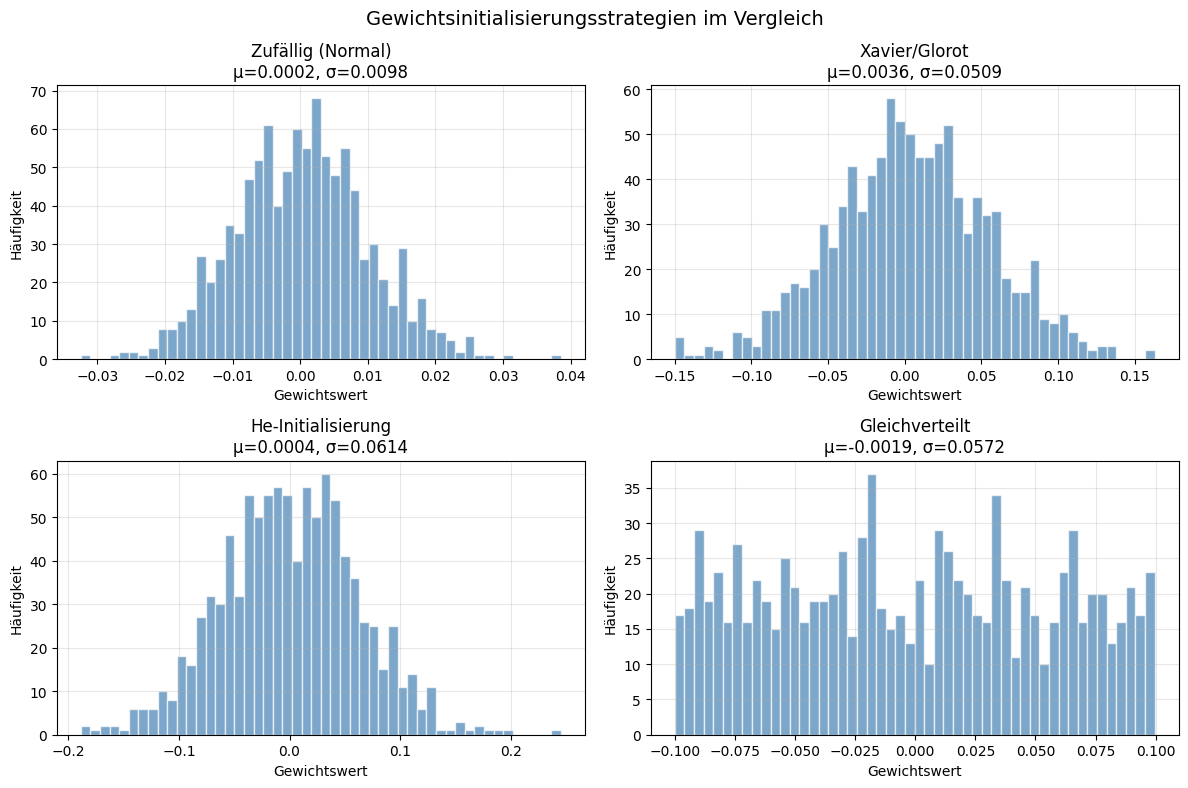

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Gewichtsinitialisierungsstrategien im Vergleich', fontsize=14)

for ax, (name, gewichte) in zip(axes.flatten(), initialisierungen.items()):
    ax.hist(gewichte, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(f'{name}\nμ={gewichte.mean():.4f}, σ={gewichte.std():.4f}')
    ax.set_xlabel('Gewichtswert')
    ax.set_ylabel('Häufigkeit')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Exercise 2

**Cell 1:**
Demonstrating the vanishing gradient problem in deep networks using the Sigmoid activation function.

In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Fortgeschrittene
# Aufgabe 2 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement a complete feedforward neural network from scratch
import numpy as np

class NeuronalesNetz:
    """Einfaches Feedforward-Netz mit einer versteckten Schicht"""
    
    def __init__(self, eingabe_groesse, versteckt_groesse, ausgabe_groesse):
        np.random.seed(42)
        # He-Initialisierung
        self.W1 = np.random.randn(eingabe_groesse, versteckt_groesse) * np.sqrt(2.0/eingabe_groesse)
        self.b1 = np.zeros((1, versteckt_groesse))
        self.W2 = np.random.randn(versteckt_groesse, ausgabe_groesse) * np.sqrt(2.0/versteckt_groesse)
        self.b2 = np.zeros((1, ausgabe_groesse))
    
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    
    def vorwaerts(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2

# Beispiel: XOR Problem
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

netz = NeuronalesNetz(2, 4, 1)
ausgabe = netz.vorwaerts(X)

print("=== Feedforward Netz – XOR Problem ===")
print(f"Eingaben:\n{X}")
print(f"\nVorhersagen (untrainiert):\n{ausgabe.round(4)}")
print(f"\nZielwerte:\n{y}")
print(f"\nNetz-Architektur: {2}-{4}-{1}")
print(f"Gewichte W1 Shape: {netz.W1.shape}")
print(f"Gewichte W2 Shape: {netz.W2.shape}")


=== Feedforward Netz – XOR Problem ===
Eingaben:
[[0 0]
 [0 1]
 [1 0]
 [1 1]]

Vorhersagen (untrainiert):
[[0.4249]
 [0.3837]
 [0.3744]
 [0.3484]]

Zielwerte:
[[0]
 [1]
 [1]
 [0]]

Netz-Architektur: 2-4-1
Gewichte W1 Shape: (2, 4)
Gewichte W2 Shape: (4, 1)


## Exercise 3

**Cell 1:**
Investigating the impact of network depth and width on the number of parameters and model capacity.

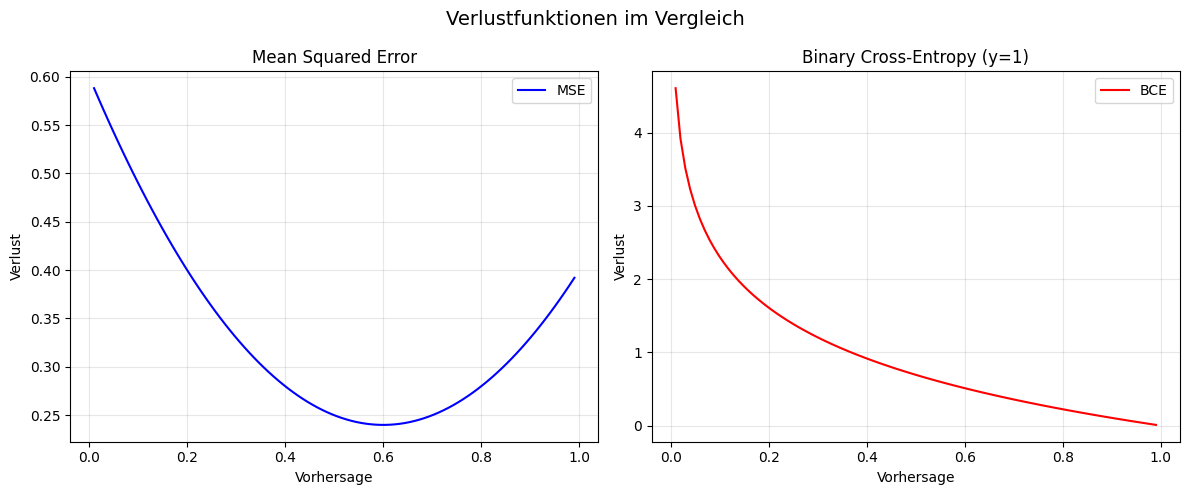

MSE (Beispiel): 0.0380
MAE (Beispiel): 0.1800


In [1]:
%matplotlib inline
# ============================================================
# educx GmbH – Neuronale Netze | Modul 2
# Lerntag 1: Grundlagen Neuronaler Netze
# Niveau: Fortgeschrittene
# Aufgabe 3 von 3
# ============================================================
# Musterlösung – lauffähig in Spyder (tf_arm conda env)
# Python-Pfad: /Users/solusprime/opt/anaconda3/envs/tf_arm/bin/python
# ============================================================

# Implement and compare common loss functions
import numpy as np
import matplotlib

import matplotlib.pyplot as plt

def mse_verlust(y_wahr, y_pred):
    """Mean Squared Error"""
    return np.mean((y_wahr - y_pred) ** 2)

def mae_verlust(y_wahr, y_pred):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_wahr - y_pred))

def binary_crossentropy(y_wahr, y_pred):
    """Binäre Kreuzentropie"""
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(y_wahr * np.log(y_pred) + (1 - y_wahr) * np.log(1 - y_pred))

# Verluste über Vorhersage-Bereich
y_wahr = np.array([1, 0, 1, 1, 0])
vorhersagen = np.linspace(0.01, 0.99, 100)

mse_werte = [mse_verlust(y_wahr, np.full(5, p)) for p in vorhersagen]
bce_werte = [binary_crossentropy(np.array([1]), np.array([p])) for p in vorhersagen]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Verlustfunktionen im Vergleich', fontsize=14)

ax1.plot(vorhersagen, mse_werte, color='blue', label='MSE')
ax1.set_title('Mean Squared Error')
ax1.set_xlabel('Vorhersage'); ax1.set_ylabel('Verlust')
ax1.grid(True, alpha=0.3); ax1.legend()

ax2.plot(vorhersagen, bce_werte, color='red', label='BCE')
ax2.set_title('Binary Cross-Entropy (y=1)')
ax2.set_xlabel('Vorhersage'); ax2.set_ylabel('Verlust')
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout()
plt.savefig('verlustfunktionen.png', dpi=100)
plt.show()
print(f"MSE (Beispiel): {mse_verlust(y_wahr, np.array([0.7, 0.2, 0.8, 0.9, 0.1])):.4f}")
print(f"MAE (Beispiel): {mae_verlust(y_wahr, np.array([0.7, 0.2, 0.8, 0.9, 0.1])):.4f}")
